In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
student=pd.read_csv("student.csv",sep=";")
health=pd.read_csv("health.csv")
lifestyle=pd.read_csv("lifestyle.csv")

print(student.shape, health.shape, lifestyle.shape)

(395, 33) (768, 9) (32561, 15)


In [3]:
student.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
health.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
lifestyle.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
lifestyle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
student = student.fillna(student.select_dtypes(include=np.number).mean())
health = health.fillna(health.select_dtypes(include=np.number).mean())
lifestyle = lifestyle.fillna(lifestyle.select_dtypes(include=np.number).mean())

In [10]:
student_df = student[['studytime', 'absences', 'G1', 'G2', 'G3']]
health_df = health[['Glucose', 'BMI', 'Age', 'Outcome']]
lifestyle_df = lifestyle[['age', 'hours.per.week', 'income']]

In [11]:
student_df.columns = ['study_hours', 'absences', 'grade1', 'grade2', 'final_grade']
health_df.columns = ['glucose', 'bmi', 'age', 'diabetes']
lifestyle_df.columns = ['age', 'work_hours', 'income']

In [12]:
student_df.describe()

,study_hours,absences,grade1,grade2,final_grade
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,2.035443,5.708861,10.908861,10.713924,10.415190
std,0.839240,8.003096,3.319195,3.761505,4.581443
min,1.000000,0.000000,3.000000,0.000000,0.000000
25%,1.000000,0.000000,8.000000,9.000000,8.000000
50%,2.000000,4.000000,11.000000,11.000000,11.000000
75%,2.000000,8.000000,13.000000,13.000000,14.000000
max,4.000000,75.000000,19.000000,19.000000,20.000000


In [13]:
lifestyle_df['income'].value_counts()

,count
income,
<=50K,24720
>50K,7841


In [14]:
health_df.groupby('diabetes')['bmi'].mean()

,bmi
diabetes,
0,30.304200
1,35.142537


In [15]:
np.mean(student_df['final_grade'])

np.float64(10.415189873417722)

In [16]:
np.median(lifestyle_df['work_hours'])

np.float64(40.0)

In [17]:
np.std(health_df['bmi'])

7.879025731540125

In [18]:
np.var(health_df['glucose'])

1020.9172617594401

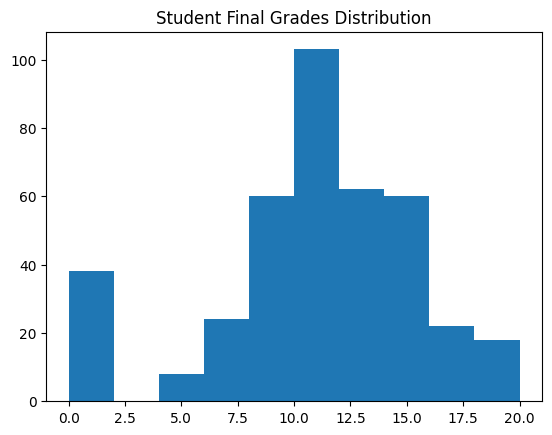

In [19]:
plt.hist(student_df['final_grade'])
plt.title("Student Final Grades Distribution")
plt.show()

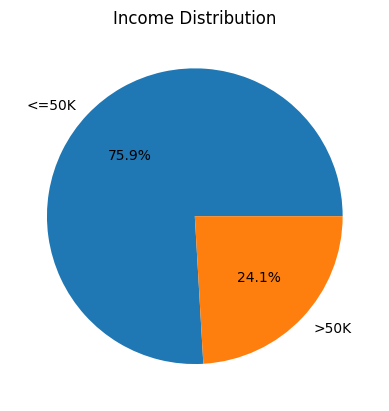

In [20]:
lifestyle_df['income'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Income Distribution")
plt.ylabel("")
plt.show()

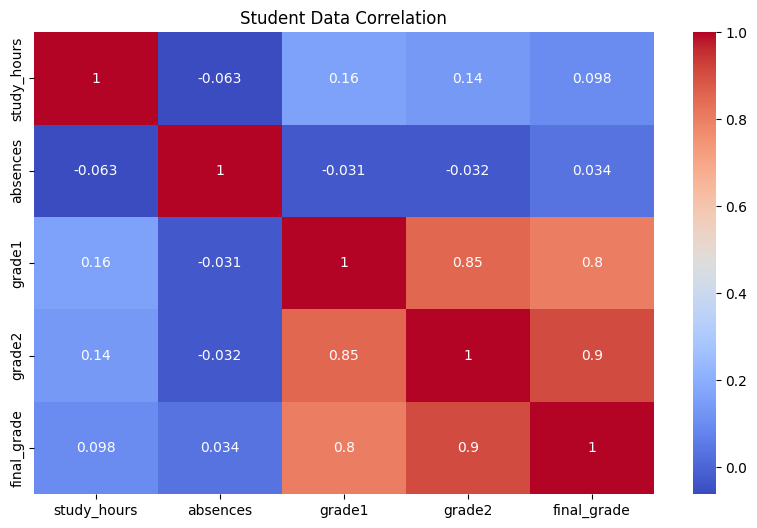

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(student_df.corr(), annot=True, cmap='coolwarm')
plt.title("Student Data Correlation")
plt.show()

In [22]:
student_df['performance_score'] = (
    student_df['grade1'] + student_df['grade2'] + student_df['final_grade']
) / 3

/tmp/ipykernel_1817/1239375356.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_df['performance_score'] = (


In [23]:
health_df['health_risk'] = health_df['bmi'] * 0.5 + health_df['glucose'] * 0.5

/tmp/ipykernel_1817/3889685595.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  health_df['health_risk'] = health_df['bmi'] * 0.5 + health_df['glucose'] * 0.5


In [24]:
lifestyle_df['life_score'] = lifestyle_df['work_hours']

/tmp/ipykernel_1817/197074434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lifestyle_df['life_score'] = lifestyle_df['work_hours']


In [25]:
df = pd.concat([
    student_df[['performance_score']].reset_index(drop=True),
    health_df[['health_risk']].reset_index(drop=True),
    lifestyle_df[['life_score']].reset_index(drop=True)
], axis=1)

df.head()

,performance_score,health_risk,life_score
0,5.666667,90.80,40
1,5.333333,55.80,18
2,8.333333,103.15,40
3,14.666667,58.55,40
4,8.666667,90.05,40


In [26]:
df = df.dropna()

In [27]:
from sklearn.cluster import KMeans

X = df

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,performance_score,health_risk,life_score,cluster
0,5.666667,90.80,40,3
1,5.333333,55.80,18,2
2,8.333333,103.15,40,3
3,14.666667,58.55,40,2
4,8.666667,90.05,40,3


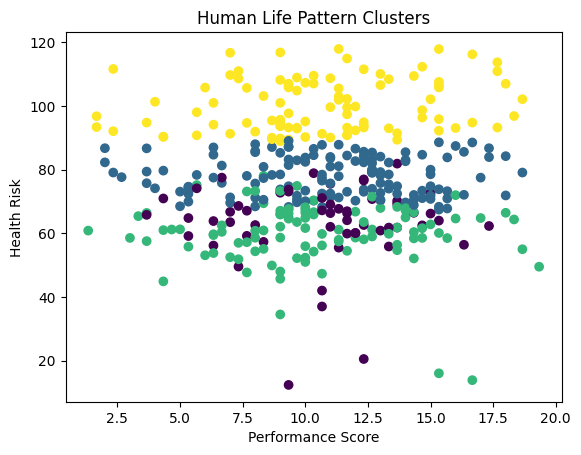

In [28]:
plt.scatter(df['performance_score'], df['health_risk'], c=df['cluster'])
plt.xlabel("Performance Score")
plt.ylabel("Health Risk")
plt.title("Human Life Pattern Clusters")
plt.show()

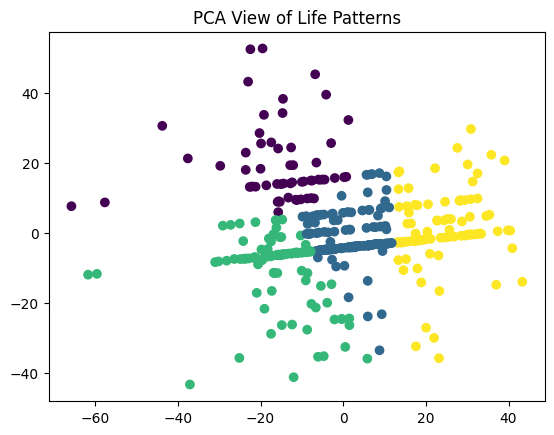

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X)

plt.scatter(components[:,0], components[:,1], c=df['cluster'])
plt.title("PCA View of Life Patterns")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df.loc[:, 'high_risk'] = (df['health_risk'] > df['health_risk'].median()).astype(int)

X = df[['performance_score', 'health_risk', 'life_score']]
y = df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [31]:
def predict_risk(performance_score, health_risk, life_score):

    input_data = np.array([[performance_score, health_risk, life_score]])
    input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        return "🔴 High Risk"
    else:
        return "🟢 Low Risk"

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [35]:
p = float(input("Enter performance score: "))
h = float(input("Enter health risk score: "))
l = float(input("Enter life score: "))

print(predict_risk(p, h, l))

Enter performance score: 8
Enter health risk score: 9
Enter life score: 6
🟢 Low Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
